In [87]:
# Importing library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import  MinMaxScaler
from tensorflow.keras.models import  Sequential
from tensorflow.keras.layers import  LSTM , Dense

Langkah 1: Inisialisasi Data Sintetis

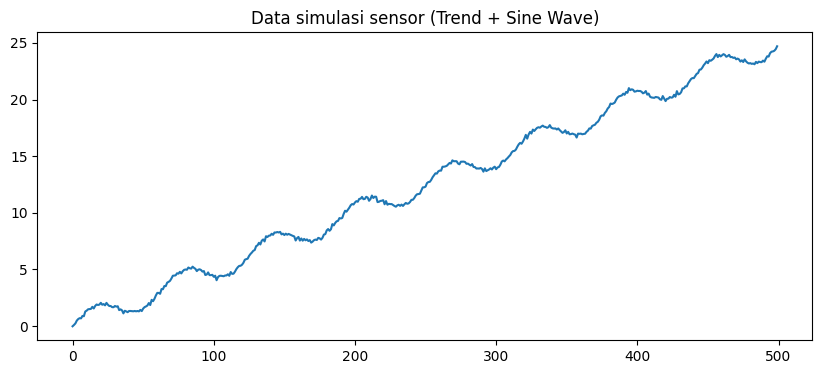

In [88]:
# 1. Membuat data gelombang dengan tren
t = np.arange(0, 500, 1)
data = np.sin(0.1 * t) + 0.05 * t + np.random.normal(0, 0.1, 500)

# Print
df = pd.DataFrame(data, columns=['Nilai_Sensor'])
plt.figure(figsize=(10,4))
plt.plot(df)
plt.title("Data simulasi sensor (Trend + Sine Wave)")
plt.show()

In [89]:
df.head()

,Nilai_Sensor
0,-0.026147
1,0.091096
2,0.226788
3,0.474402
4,0.612603


Langkah 2: Normalisasi Data (Scaling)

In [90]:
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

Langkah 3: Membuat Struktur Jendela Waktu (Windowing)

In [91]:
def create_windowed_data(data, window_size=10):
    x, y = [], []
    for i in range(len(data) - window_size):
        x.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(x), np.array(y)

window_size = 10
x, y = create_windowed_data(df_scaled, window_size)

# reshape ke format 3D [samples, Timestamps, Features]
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

print(f"Bentuk data x (3D): {x.shape}")

Bentuk data x (3D): (490, 10, 1)


Langkah 4: Membangun Arsitektur LSTM

In [92]:
model = Sequential([
    LSTM(units=50, activation='relu', input_shape=(window_size, 1)),
    Dense(units=1)
])

model.compile(optimizer="adam", loss='mean_squared_error')
model.summary()

/home/pratama/dev-python/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Langkah 5: Pelatihan Model (Training)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1723 - val_loss: 0.4343
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0701 - val_loss: 0.1194
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0114 - val_loss: 0.0019
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - val_loss: 0.0043
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 0.0054
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.8712e-04 - val_loss: 0.0059
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6519e-04 - val_loss: 0.0024
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1965e-04 - val_loss: 0.0016
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9984e-04 - val_loss: 0.0018
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8511e-04 - val_loss: 0.0015
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8363e-04 - val_loss: 0.0017
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 

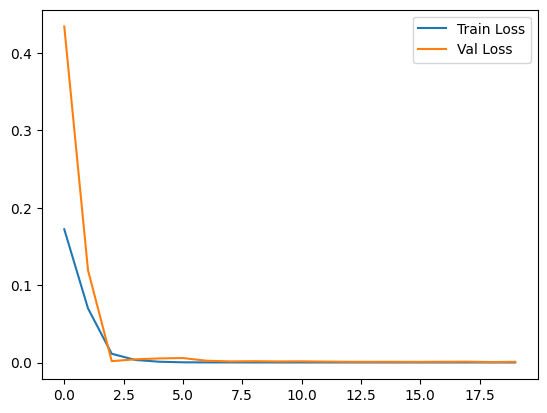

In [93]:
# Membagi data train (80%) dan test (20%)
split = int(0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

# Training
history = model.fit(x_train, y_train, epochs=20, batch_size=32,
                    validation_data=(x_test, y_test), verbose=1)

# Visualisasi loss
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

Langkah 6: Prediksi dan Inverse Transform

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


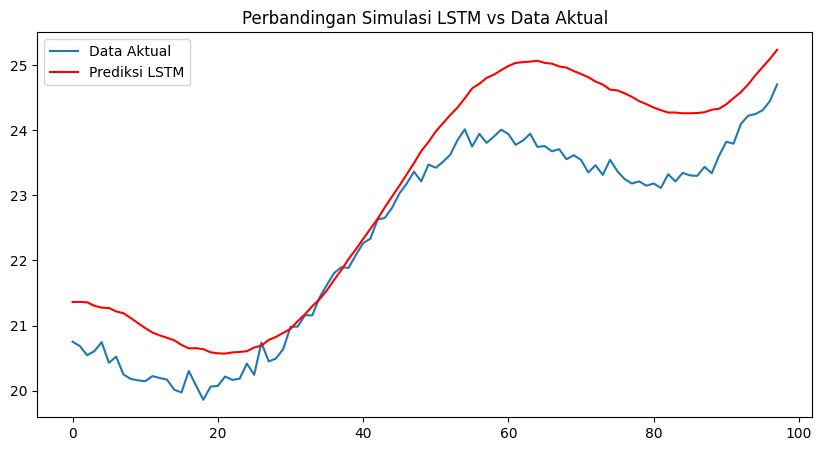

In [94]:
y_pred_scaled = model.predict(x_test)
# Mengembalikan ke skala asli
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualisasi Hasil Akhir
plt.figure(figsize=(10, 5))
plt.plot(y_actual, label='Data Aktual')
plt.plot(y_pred, label='Prediksi LSTM', color='red')
plt.legend()
plt.title("Perbandingan Simulasi LSTM vs Data Aktual")
plt.show()

Simulasi What-if

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


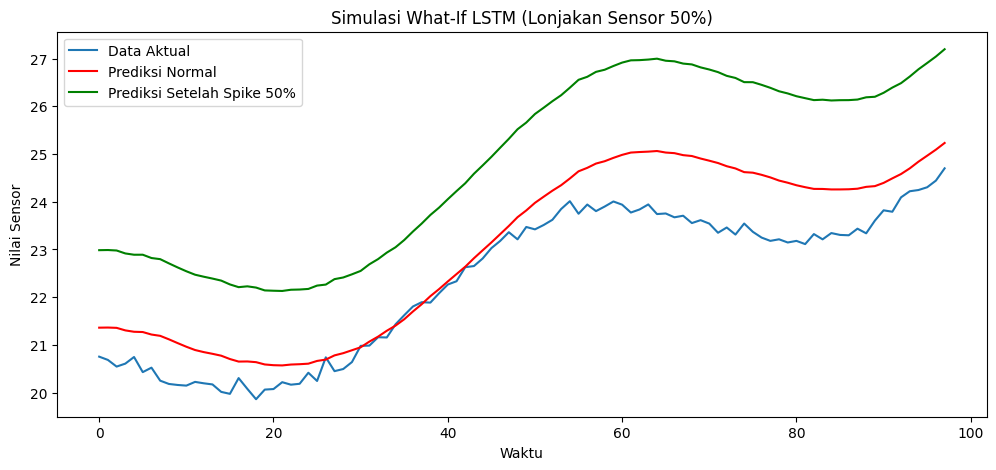

In [96]:
# Ambil data test
sample = x_test.copy()

# Prediksi normal
pred_normal_scaled = model.predict(sample)

# Copy data untuk simulasi
sample_spike = sample.copy()

# Simulasi lonjakan 50% pada sensor terakhir tiap window
sample_spike[:, -1, 0] = sample_spike[:, -1, 0] * 1.5

# Prediksi setelah spike
pred_spike_scaled = model.predict(sample_spike)

# Kembalikan ke skala asli
pred_normal = scaler.inverse_transform(pred_normal_scaled)
pred_spike = scaler.inverse_transform(pred_spike_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Visualisasi
plt.figure(figsize=(12,5))

plt.plot(y_actual, label='Data Aktual')
plt.plot(pred_normal, label='Prediksi Normal', color='red')
plt.plot(pred_spike, label='Prediksi Setelah Spike 50%', color='green')

plt.legend()
plt.title("Simulasi What-If LSTM (Lonjakan Sensor 50%)")
plt.xlabel("Waktu")
plt.ylabel("Nilai Sensor")

plt.show()